<a href="https://colab.research.google.com/github/haujla2391/CIFAR-10-CNN/blob/main/CSCI4170_hw5_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/data?select=cards.csv

In [112]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import Dataset,DataLoader

In [113]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device('cpu')

#### This dataset is of playing card images. There are 8155 images, 94% are train, 3% val, 3% test. 53 classes.

In [114]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")

df = pd.read_csv(path+"/cards.csv")
print(df.info(), "\n")

print("Train: ", np.sum(df['data set'] == "train"))
print("Validation: ", np.sum(df['data set'] == "valid"))
print("Test: ", np.sum(df['data set'] == "test"))

classes = df['labels'].unique()
print("Number of classes: ", len(classes))


Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8155 entries, 0 to 8154
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class index  8155 non-null   int64 
 1   filepaths    8155 non-null   object
 2   labels       8155 non-null   object
 3   card type    8155 non-null   object
 4   data set     8155 non-null   object
dtypes: int64(1), object(4)
memory usage: 318.7+ KB
None 

Train:  7625
Validation:  265
Test:  265
Number of classes:  53


In [115]:
transform_data = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(path+"/train", transform_data)
valid_dataset = ImageFolder(path+"/valid", transform_data)
test_dataset = ImageFolder(path+"/test", transform_data)

eight of hearts


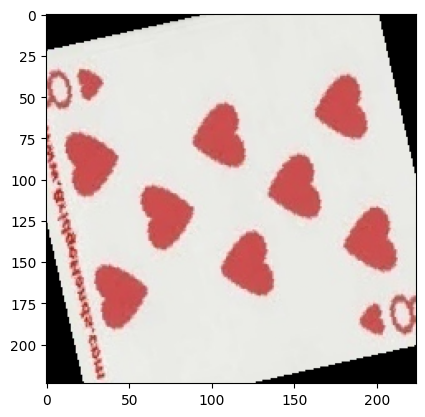

In [116]:
image, label = train_dataset[1000]
print(classes[label])
plt.imshow(image.permute(2,1,0))

### Hyperparameters

In [117]:
batch_size = 32
num_epochs = 50
lr = 0.00001
weight_decay = 0.0001

### Data loaders

In [118]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Model

In [119]:
class MyCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
    self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(in_features=256*(14*14), out_features=128)
    self.fc2 = nn.Linear(in_features=128, out_features=53)
    self.relu = nn.ReLU()
    self.bn1 = nn.BatchNorm2d(32)
    self.bn2 = nn.BatchNorm2d(64)
    self.bn3 = nn.BatchNorm2d(128)
    self.bn4 = nn.BatchNorm2d(256)
    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv3(x)
    x = self.bn3(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.conv4(x)
    x = self.bn4(x)
    x = self.relu(x)
    x = self.pool(x)

    x = self.flatten(x)

    x = self.fc1(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.fc2(x)
    return x

In [120]:
model = MyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [121]:
def train(dataloader, model, criterion, optimizer):
  size = len(dataloader.dataset)
  model.train()
  total_loss = 0.0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    preds = model(X)
    loss = criterion(preds, y)

    total_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  return total_loss / len(dataloader)

In [122]:
def val(dataloader, model, criterion):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            val_loss += criterion(preds, y).item()
            correct += (preds.argmax(1) == y).type(torch.float).sum().item()
    val_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {val_loss:>8f} \n")
    return val_loss, correct

### Train and validation phase

In [123]:
train_losses, val_losses = [], []

for epoch in range(num_epochs):
  print("Epoch: ", epoch+1)
  train_avg_loss = train(train_loader, model, criterion, optimizer)
  val_avg_loss, _ = val(val_loader, model, criterion)

  train_losses.append(train_avg_loss)
  val_losses.append(val_avg_loss)


Epoch:  1
Test Error: 
 Accuracy: 10.6%, Avg loss: 3.676526 

Epoch:  2
Test Error: 
 Accuracy: 16.2%, Avg loss: 3.436687 

Epoch:  3
Test Error: 
 Accuracy: 23.8%, Avg loss: 3.203155 

Epoch:  4
Test Error: 
 Accuracy: 26.8%, Avg loss: 3.051278 

Epoch:  5
Test Error: 
 Accuracy: 27.5%, Avg loss: 2.886149 

Epoch:  6
Test Error: 
 Accuracy: 36.2%, Avg loss: 2.668860 

Epoch:  7
Test Error: 
 Accuracy: 35.8%, Avg loss: 2.588163 

Epoch:  8
Test Error: 
 Accuracy: 40.4%, Avg loss: 2.398167 

Epoch:  9
Test Error: 
 Accuracy: 39.6%, Avg loss: 2.310399 

Epoch:  10
Test Error: 
 Accuracy: 43.4%, Avg loss: 2.200652 

Epoch:  11
Test Error: 
 Accuracy: 43.8%, Avg loss: 2.132700 

Epoch:  12
Test Error: 
 Accuracy: 44.9%, Avg loss: 2.088463 

Epoch:  13
Test Error: 
 Accuracy: 43.8%, Avg loss: 2.012748 

Epoch:  14
Test Error: 
 Accuracy: 46.8%, Avg loss: 1.967927 

Epoch:  15
Test Error: 
 Accuracy: 50.9%, Avg loss: 1.903316 

Epoch:  16
Test Error: 
 Accuracy: 47.9%, Avg loss: 1.878237 

E

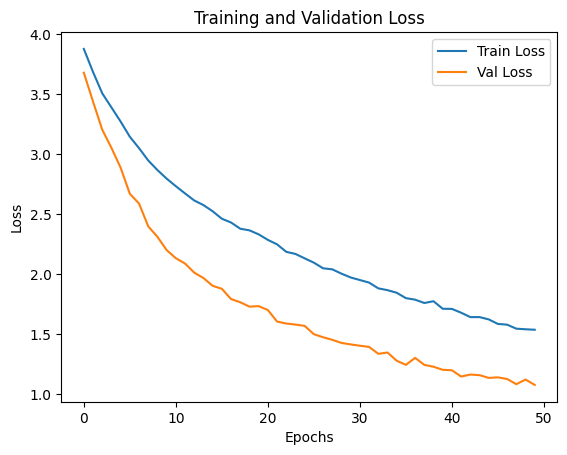

In [124]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### Test phase

In [125]:
_, accuracy_test = val(test_loader, model, criterion)

Test Error: 
 Accuracy: 74.0%, Avg loss: 1.246099 



The final accuracy is 82.6% which is pretty good. I believe after more epochs, the accuracy could reach 90%.

# Transfer Learning

### Chosen model: GoogLeNet Inception V3

In [126]:
import timm
model = timm.create_model('inception_v3', pretrained=True, num_classes=53)

In [127]:
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

### Train and validation phase for Transfer Learning model

Epoch: 1
Test Error: 
 Accuracy: 84.5%, Avg loss: 0.632038 

Epoch: 2
Test Error: 
 Accuracy: 83.0%, Avg loss: 0.797579 

Epoch: 3
Test Error: 
 Accuracy: 83.4%, Avg loss: 0.709763 

Epoch: 4
Test Error: 
 Accuracy: 85.7%, Avg loss: 0.779771 

Epoch: 5
Test Error: 
 Accuracy: 86.0%, Avg loss: 0.645654 

Epoch: 6
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.735363 

Epoch: 7
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.674832 

Epoch: 8
Test Error: 
 Accuracy: 85.3%, Avg loss: 0.664360 

Epoch: 9
Test Error: 
 Accuracy: 85.7%, Avg loss: 0.649005 

Epoch: 10
Test Error: 
 Accuracy: 84.2%, Avg loss: 0.706220 

Epoch: 11
Test Error: 
 Accuracy: 84.5%, Avg loss: 0.783621 

Epoch: 12
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.756653 

Epoch: 13
Test Error: 
 Accuracy: 85.3%, Avg loss: 0.628252 

Epoch: 14
Test Error: 
 Accuracy: 84.9%, Avg loss: 0.772010 

Epoch: 15
Test Error: 
 Accuracy: 83.8%, Avg loss: 0.748583 



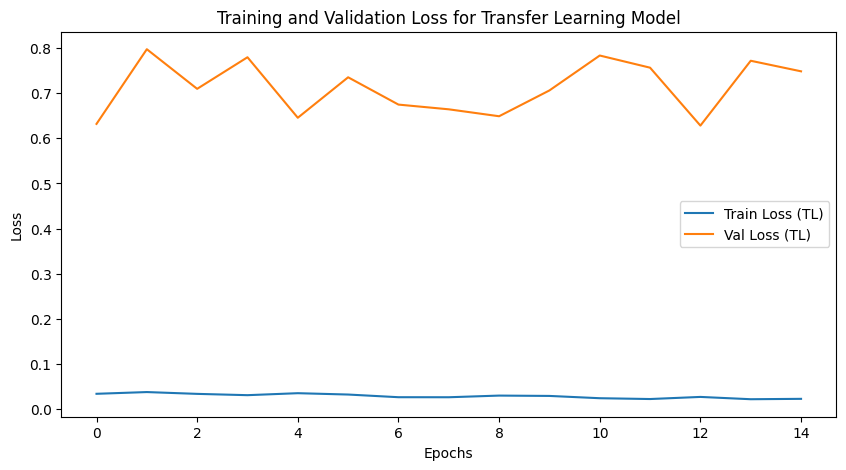

In [130]:
train_losses_tf, val_losses_tf = [], []

for epoch in range(15):
  print(f"Epoch: {epoch+1}")
  train_avg_loss_tf = train(train_loader, model, criterion, optimizer)
  val_avg_loss_tf, _ = val(val_loader, model, criterion)

  train_losses_tf.append(train_avg_loss_tf)
  val_losses_tf.append(val_avg_loss_tf)


plt.figure(figsize=(10, 5))
plt.plot(train_losses_tf, label='Train Loss (TL)')
plt.plot(val_losses_tf, label='Val Loss (TL)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss for Transfer Learning Model')
plt.show()

### Test phase for Transfer Learning model

In [131]:
_, accuracy_test_tf_final = val(test_loader, model, criterion)

Test Error: 
 Accuracy: 83.0%, Avg loss: 0.747309 



This model got a slightly worse accuracy than the CNN I made. The graph shows that this model has overfitted and that can be why the test accuracy is not as high as the train accuracy. Also, I think normalizing the data to ImageNet's mean and std would help this accuracy since Inception used those scales.

# Data Augmentation

I have added a line in the data transforms where I do a random rotation of 15 degrees. After re running all the code using that augmentation, the CNN does worse with 74% accuracy but the transfer learning model does better with 83% accuracy.